# Predicción de Abandono, Matriculación y Graduación de Estudiantes

**Proyecto de Machine Learning**

Este notebook recoge el proceso completo y final seguido para construir un modelo de clasificación
que predice si un estudiante universitario terminará en situación de **Dropout** (abandono),
**Enrolled** (sigue matriculado) o **Graduate** (se gradúa).

El notebook está dividido en dos partes:

- **Parte 1 — EDA**: describe el dataset, analiza la distribución del target, ejecuta ANOVA/Chi-cuadrado
  de cada variable frente al target, identifica el data leakage en `Curricular units` y revisa la
  multicolinealidad entre numéricas.
- **Parte 2 — Modelado**: parte directamente de las conclusiones del EDA (citadas con sus cifras exactas
  donde aporta) para construir, entrenar, ajustar y evaluar el modelo final.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, chi2_contingency, loguniform

from toolbox_ml.eda.core import describe_df, tipifica_variables
%matplotlib inline
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

import joblib

# Scikit-learn: Selección de modelos y preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Scikit-learn: Modelos y métricas
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, f1_score, confusion_matrix,
                              ConfusionMatrixDisplay)

# Imbalanced-learn (Manejo de clases desbalanceadas)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Configuraciones iniciales
RANDOM_STATE = 42
sns.set_style('whitegrid')

# Parte 1 — Análisis Exploratorio de Datos (EDA)

In [107]:
df = pd.read_csv("src/data_sample/data.csv", sep=';') 
df.shape

(4424, 37)

In [108]:
# PRIMER VISTAZO
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [109]:
df.columns.tolist()

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance\t',
 'Previous qualification',
 'Previous qualification (grade)',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation r

In [110]:
# LIMPIEZA DE NOMBRES
df.columns = df.columns.str.strip()
df.columns.tolist()

['Marital status',
 'Application mode',
 'Application order',
 'Course',
 'Daytime/evening attendance',
 'Previous qualification',
 'Previous qualification (grade)',
 'Nacionality',
 "Mother's qualification",
 "Father's qualification",
 "Mother's occupation",
 "Father's occupation",
 'Admission grade',
 'Displaced',
 'Educational special needs',
 'Debtor',
 'Tuition fees up to date',
 'Gender',
 'Scholarship holder',
 'Age at enrollment',
 'International',
 'Curricular units 1st sem (credited)',
 'Curricular units 1st sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Curricular units 1st sem (approved)',
 'Curricular units 1st sem (grade)',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)',
 'Unemployment rate',
 'Inflation rat

In [111]:
target_col = 'Target'

cat_cols = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'
]

num_cols = [col for col in df.columns if col not in cat_cols + [target_col]]

print("Categóricas:", len(cat_cols))
print("Numéricas:", len(num_cols))
print(num_cols)

Categóricas: 18
Numéricas: 18
['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


In [112]:
df.columns = df.columns.str.strip()
# USANDO NUESTRO PAQUETE DE ANALISIS EDA Y ML
resumen = describe_df(df)
resumen

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
Marital status,int64,0.0,6,0.135624
Application mode,int64,0.0,18,0.406872
Application order,int64,0.0,8,0.180832
Course,int64,0.0,17,0.384268
Daytime/evening attendance,int64,0.0,2,0.045208
Previous qualification,int64,0.0,17,0.384268
Previous qualification (grade),float64,0.0,101,2.283002
Nacionality,int64,0.0,21,0.474684
Mother's qualification,int64,0.0,29,0.655515
Father's qualification,int64,0.0,34,0.768535


### A destacar

1. **0% nulos en todas las columnas** — confirma lo que decía la ficha del dataset, no hay que imputar nada.
2. **`Target`** con 3 valores únicos — confirma el problema de clasificación multiclase (Dropout / Enrolled / Graduate).
3. **Ojo con `Unemployment rate`, `Inflation rate`, `GDP`** — son `float64` pero solo tienen 9-10 valores únicos. Esto tiene sentido: son indicadores macroeconómicos por año de matrícula, no algo que varíe por estudiante individualmente. Es decir, muchos estudiantes comparten el mismo valor porque se matricularon el mismo año. Esto es relevante de cara al análisis (no es ruido, es una variable "de cohorte").
4. **variables binarias** (`Displaced`, `Debtor`, `Gender`, `Scholarship holder`, etc. con 2 valores) — coincide con lo que ya hemos clasificado como categóricas.
5. **`Admission grade`, `Curricular units 1st/2nd sem (grade)`** tienen alta cardinalidad (14-18%), como se espera de notas continuas.

In [113]:
#  VER SI HAY UNA CLASIFICACIÓN ADECUADA

tipos = tipifica_variables(df, umbral_categorica=10, umbral_continua=70.0)
tipos

,Nombre variable,Tipo sugerido
0,Marital status,Categorica
1,Application mode,Numérica Discreta
2,Application order,Categorica
3,Course,Numérica Discreta
4,Daytime/evening attendance,Binaria
5,Previous qualification,Numérica Discreta
6,Previous qualification (grade),Numérica Discreta
7,Nacionality,Numérica Discreta
8,Mother's qualification,Numérica Discreta
9,Father's qualification,Numérica Discreta


### La clasificación automática no es fiable aquí

`tipifica_variables` solo se basa en la **cardinalidad** de cada columna (número de valores únicos frente a los umbrales definidos), sin conocer el significado real de la variable. Esto lleva a varios errores de clasificación:

1. **Categóricas nominales marcadas como "Numérica Discreta"**: `Application mode`, `Course`, `Previous qualification`, `Nacionality`, `Mother's/Father's qualification`, `Mother's/Father's occupation`. Son códigos que representan categorías (carrera, nacionalidad, ocupación...), no cantidades numéricas, aunque tengan muchos valores únicos.

2. **Variables continuas marcadas como "Numérica Discreta"**: `Admission grade` y las `Curricular units (grade)` de 1er y 2º semestre son notas continuas, no discretas.

3. **Variables continuas marcadas como "Categórica"**: `Unemployment rate`, `Inflation rate`, `GDP` y `Curricular units 2nd sem (without evaluations)`. Al tener pocos valores únicos (9-10), caen por debajo del umbral de cardinalidad y se etiquetan como categóricas, aunque conceptualmente sean indicadores numéricos continuos (de hecho, `Unemployment rate`, `Inflation rate` y `GDP` son indicadores macroeconómicos por año de matrícula, no por estudiante).

4. **`Application order`** cae en categórica por umbral, aunque conceptualmente es más bien ordinal.

**Conclusión**: para el resto del EDA usamos una clasificación manual basada en el diccionario de variables del dataset, en lugar de confiar en el resultado automático de `tipifica_variables`.

In [114]:
target_col = 'Target'

cat_cols = ['Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

num_cols = ['Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP']

# comprobación de que las listas cuadran con el total de columnas
assert len(cat_cols) + len(num_cols) + 1 == df.shape[1]
print(f"Categóricas: {len(cat_cols)} | Numéricas: {len(num_cols)} | Target: 1 | Total: {df.shape[1]}")

Categóricas: 18 | Numéricas: 18 | Target: 1 | Total: 37


In [115]:
# Distribución del target
df[target_col].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [116]:
df[target_col].value_counts(normalize=True) * 100

Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64

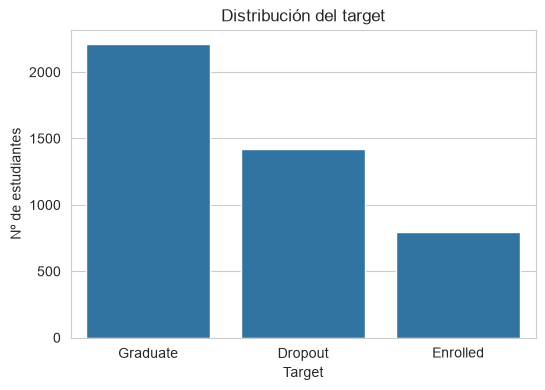

<Figure size 640x480 with 0 Axes>

In [117]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col, order=df[target_col].value_counts().index)
plt.title("Distribución del target")
plt.ylabel("Nº de estudiantes")
plt.show()
plt.savefig("src/img/Distribución del target.png")

**Observaciones:**
- Existe un desbalance moderado hacia la clase `Graduate` (~50%), seguida de `Dropout` (~32%) y `Enrolled` como clara minoritaria (~18%).
- De cara al modelado, esto implica que **accuracy no será una métrica fiable por sí sola** y convendrá usar métricas como F1-score macro o revisar la matriz de confusión por clase.
- La clase minoritaria (`Enrolled`) requerirá especial atención para evitar que el modelo la ignore en favor de las clases mayoritarias.

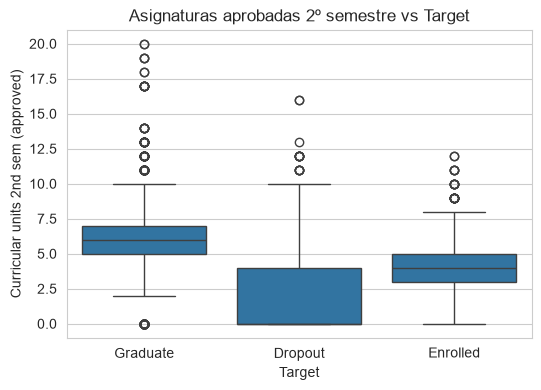

<Figure size 640x480 with 0 Axes>

In [118]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x=target_col, y='Curricular units 2nd sem (approved)', order=df[target_col].value_counts().index)
plt.title("Asignaturas aprobadas 2º semestre vs Target")
plt.show()
plt.savefig("src/img/Asignaturas aprobadas 2º semestre vs Target.png")

In [119]:
df.groupby(target_col)['Curricular units 2nd sem (approved)'].median()

Target
Dropout     0.0
Enrolled    4.0
Graduate    6.0
Name: Curricular units 2nd sem (approved), dtype: float64

#### Ejemplo de variable con posible fuga de datos

`Curricular units 2nd sem (approved)` — mediana por clase del target:

| Target | Mediana |
|---|---|
| Dropout | 0.0 |
| Enrolled | 4.0 |
| Graduate | 6.0 |

La separación entre clases es prácticamente total: quienes abandonan tienen mediana 0, quienes se gradúan mediana 6. Esto confirma la sospecha de que las variables `Curricular units 1st/2nd sem (...)` son consecuencia del resultado final más que un predictor independiente de él (data leakage). Se deja anotado para la fase de modelado, donde habrá que decidir si se excluyen, se usan parcialmente (solo 1er semestre) o se incluyen asumiendo esta limitación.

In [120]:
#ANOVA COMPLETO PARA LAS 18 NUMÉRICAS

resultados_num = []
for col in num_cols:
    grupos = [df[df[target_col] == cat][col] for cat in df[target_col].unique()]
    stat, pvalue = f_oneway(*grupos)
    resultados_num.append((col, stat, pvalue))

anova_df = pd.DataFrame(resultados_num, columns=['variable', 'F_stat', 'p_value'])
anova_df = anova_df.sort_values('p_value')
anova_df

,variable,F_stat,p_value
12,Curricular units 2nd sem (approved),1410.732938,0.000000e+00
13,Curricular units 2nd sem (grade),1134.109544,0.000000e+00
6,Curricular units 1st sem (approved),859.866768,3.649472e-316
7,Curricular units 1st sem (grade),713.517328,2.803052e-269
2,Age at enrollment,154.712071,1.138849e-65
11,Curricular units 2nd sem (evaluations),87.801092,4.039137e-38
10,Curricular units 2nd sem (enrolled),75.591910,5.244430e-33
4,Curricular units 1st sem (enrolled),59.467391,3.272852e-26
5,Curricular units 1st sem (evaluations),37.527840,6.897115e-17
1,Admission grade,35.648604,4.380466e-16


#### ANOVA — Variables numéricas vs Target

17 de las 18 variables numéricas muestran relación estadísticamente significativa con el target (p < 0.05). Solo `Inflation rate` no es significativa (p=0.175).

**Variables con mayor relación (posible data leakage):**
Las 4 variables con F_stat más alto son todas del bloque `Curricular units 1st/2nd sem (approved/grade)`, confirmando la sospecha de fuga de datos ya observada en el boxplot: estas variables son casi consecuencia directa del resultado académico final, no predictores independientes disponibles en el momento de matrícula.

**Variables "limpias" (disponibles en el momento de matrícula) con relación fuerte:**
- `Age at enrollment` (F=154.71) — la más destacada de este grupo
- `Admission grade` (F=35.65)
- `Previous qualification (grade)` (F=27.73)

**Variables macroeconómicas (de cohorte, por año de matrícula):**
`Unemployment rate` y `GDP` son significativas pero con relación débil (F≈5-6). `Inflation rate` no resulta significativa.

**Nota para modelado:** de cara a un modelo con utilidad práctica real (predicción temprana), convendrá evaluar excluir o tratar con cautela las variables `Curricular units` por su alto riesgo de data leakage.

In [121]:
# CHI CUADRADO CATEGÓRICAS vs TARGET

resultados_cat = []
for col in cat_cols:
    tabla = pd.crosstab(df[col], df[target_col])
    chi2, p, dof, expected = chi2_contingency(tabla)
    resultados_cat.append((col, chi2, p))

chi_df = pd.DataFrame(resultados_cat, columns=['variable', 'chi2', 'p_value'])
chi_df = chi_df.sort_values('p_value')
chi_df

,variable,chi2,p_value
14,Tuition fees up to date,823.552724,1.471628e-179
3,Course,558.284474,2.316571e-97
16,Scholarship holder,409.943055,9.593930e-90
1,Application mode,466.513683,1.964657e-77
13,Debtor,259.333220,4.858552e-57
15,Gender,233.266432,2.222480e-51
9,Mother's occupation,291.921705,1.630859e-31
5,Previous qualification,219.680709,7.160305e-30
7,Mother's qualification,217.952131,5.823844e-21
8,Father's qualification,225.000783,3.175007e-19


In [122]:
# verificar cuántos estudiantes hay por nacionalidad, porque si la mayoría son de 1-2 países y 
# el resto tiene 1-2 estudiantes cada uno, el resultado no es muy interpretable

df['Nacionality'].value_counts()

Nacionality
1      4314
41       38
26       14
6        13
22       13
24        5
103       3
11        3
100       3
62        2
25        2
21        2
101       2
2         2
105       2
13        1
32        1
109       1
108       1
14        1
17        1
Name: count, dtype: int64

#### Chi-cuadrado — Variables categóricas vs Target

15 de las 18 variables categóricas muestran relación estadísticamente significativa con el target (p < 0.05).

**Variables más relevantes (relacionadas con situación económica/administrativa):**
- `Tuition fees up to date` (chi2=823.55) — la variable categórica más relevante de todo el dataset
- `Scholarship holder` (chi2=409.94)
- `Debtor` (chi2=259.33)

Estas tres sugieren que la **situación económica del estudiante** es uno de los factores más determinantes en el abandono/graduación.

**Otras variables destacadas:**
`Course` y `Application mode` también muestran relación fuerte, indicando que ciertas carreras o vías de acceso tienen patrones de abandono/graduación muy distintos.

**Variables no significativas:**
- `Educational special needs` (p=0.725) e `International` (p=0.527): probablemente por muy pocos casos positivos en el dataset.
- `Nacionality` (p=0.242): el 97.5% de los estudiantes son de nacionalidad portuguesa (4314 de 4424), y el resto se reparte en 20 nacionalidades con muy pocos casos cada una (algunas con 1-2 estudiantes). Esto provoca frecuencias esperadas muy bajas en la tabla de contingencia, restando fiabilidad al test de Chi-cuadrado. No se puede concluir que no haya relación, solo que el test carece de potencia estadística con tan poca representación por categoría.

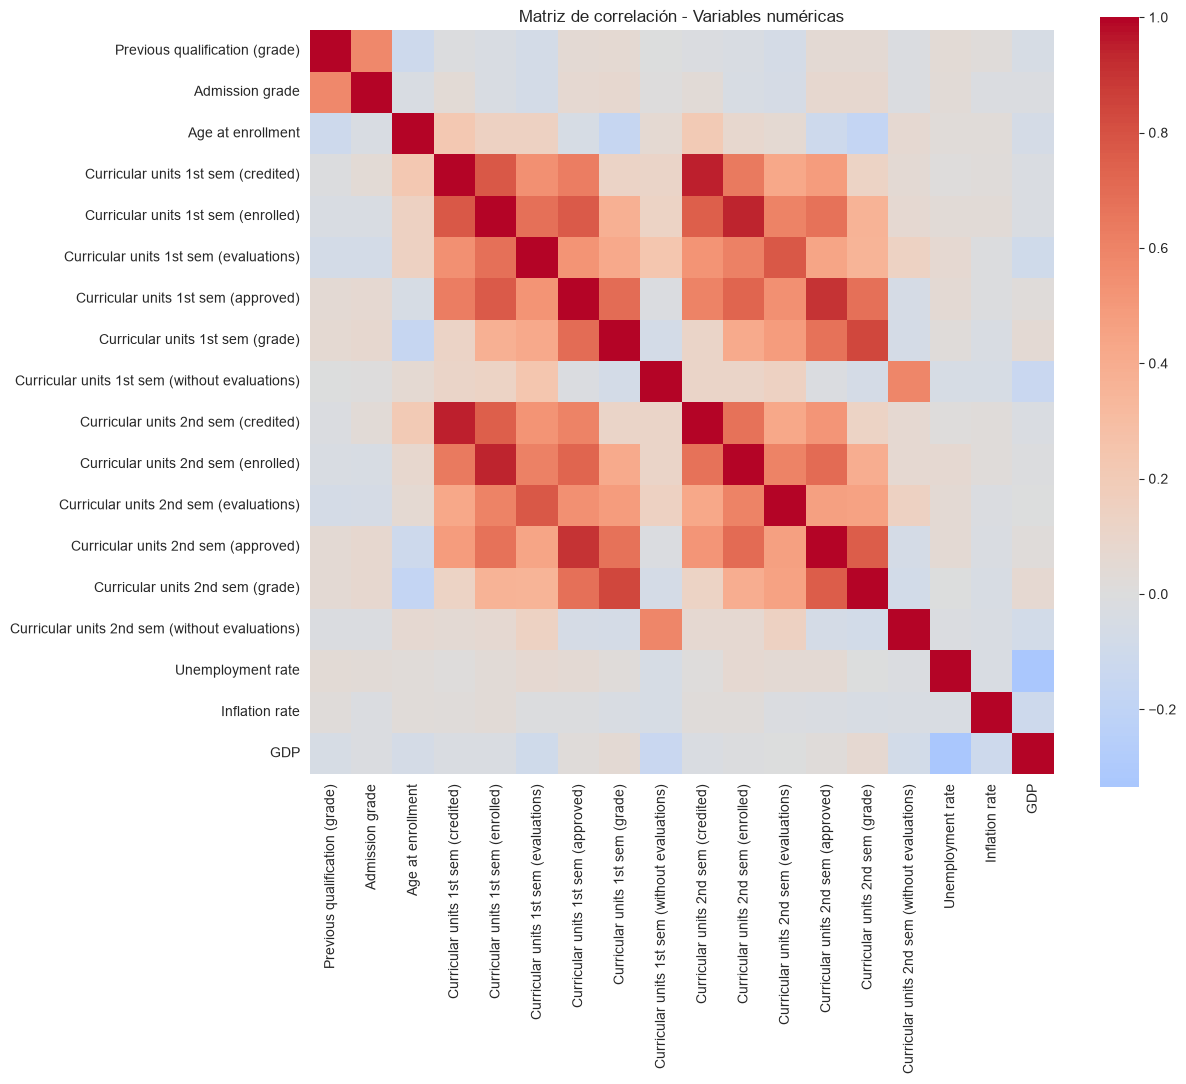

<Figure size 640x480 with 0 Axes>

In [123]:
# MATRIZ CORRELACIÓN ENTRE NUMÉRICAS

plt.figure(figsize=(12,10))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title("Matriz de correlación - Variables numéricas")
plt.show()
plt.savefig("src/img/Matriz de correlación - Variables numéricas.png")

In [124]:
# PARES CON CORRELACIÓN MUY ALTA (candidatos a redundancia)

# nos quedamos con pares de variables distintas y correlación absoluta alta
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]  # quitamos la diagonal (autocorrelación=1)
corr_pairs = corr_pairs.sort_values(ascending=False)

# eliminamos duplicados (A-B y B-A son el mismo par)
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]
top_corr = corr_pairs.drop_duplicates().head(15)
top_corr

Curricular units 2nd sem (credited)     Curricular units 1st sem (credited)       0.944811
Curricular units 2nd sem (enrolled)     Curricular units 1st sem (enrolled)       0.942627
Curricular units 2nd sem (approved)     Curricular units 1st sem (approved)       0.904002
Curricular units 1st sem (grade)        Curricular units 2nd sem (grade)          0.837170
Curricular units 2nd sem (evaluations)  Curricular units 1st sem (evaluations)    0.778863
Curricular units 1st sem (credited)     Curricular units 1st sem (enrolled)       0.774344
Curricular units 1st sem (approved)     Curricular units 1st sem (enrolled)       0.769083
Curricular units 2nd sem (approved)     Curricular units 2nd sem (grade)          0.760804
Curricular units 1st sem (enrolled)     Curricular units 2nd sem (credited)       0.753747
Curricular units 1st sem (approved)     Curricular units 2nd sem (enrolled)       0.733772
Curricular units 2nd sem (enrolled)     Curricular units 2nd sem (approved)       0.703258

#### Conclusiones generales del mini EDA

##### 1. Estructura del dataset
- **4424 estudiantes, 37 columnas** (36 features + 1 target), sin valores nulos.
- **18 variables categóricas** y **18 numéricas**, según clasificación manual basada en el diccionario de variables (la función automática `tipifica_variables` clasificó mal varias columnas por depender solo de cardinalidad, no de significado semántico).

##### 2. Target: clasificación multiclase con desbalance moderado
| Clase | Nº estudiantes | % |
|---|---|---|
| Graduate | 2209 | 49.9% |
| Dropout | 1421 | 32.1% |
| Enrolled | 794 | 17.9% |

De cara al modelado: evitar depender solo de accuracy, priorizar métricas como F1 macro y vigilar el rendimiento sobre `Enrolled` (clase minoritaria).

##### 3. Alerta importante: posible fuga de datos (data leakage)
Las variables `Curricular units 1st/2nd sem (approved, grade, enrolled, evaluations...)` muestran una relación extremadamente fuerte con el target (F_stat de hasta 1410 en ANOVA), y un ejemplo concreto lo confirma: la mediana de asignaturas aprobadas en 2º semestre es **0 para Dropout** y **6 para Graduate**. 

Estas variables son casi consecuencia directa del resultado final, no predictores independientes disponibles en el momento de la matrícula. **Habrá que decidir en la fase de modelado** si se excluyen, se usan parcialmente (solo 1er semestre, para un modelo de alerta a mitad de curso) o se incluyen asumiendo esta limitación.

##### 4. Variables numéricas "limpias" con relación real (disponibles en matrícula)
- `Age at enrollment` (F=154.71) — la más destacada de este grupo
- `Admission grade` (F=35.65)
- `Previous qualification (grade)` (F=27.73)

Estas son las candidatas más sólidas para un modelo de predicción temprana sin leakage.

##### 5. Variables categóricas más relevantes
Los factores económicos/administrativos destacan con claridad:
- `Tuition fees up to date` (chi2=823.55) — la variable categórica más relevante del dataset
- `Scholarship holder` (chi2=409.94)
- `Debtor` (chi2=259.33)

También `Course` y `Application mode` muestran relación fuerte, sugiriendo diferencias notables de abandono/graduación según carrera y vía de acceso.

##### 6. Variables sin relación significativa (o con test poco fiable)
- `Inflation rate` (numérica, p=0.175)
- `Educational special needs` e `International` (categóricas, muy pocos casos positivos)
- `Nacionality` (categórica, p=0.242 — pero el 97.5% de estudiantes son de una sola nacionalidad, lo que invalida la fiabilidad del test; se recomienda recodificar como binaria Portuguesa/Extranjera si se quiere aprovechar)

##### 7. Variables macroeconómicas (de cohorte)
`Unemployment rate` y `GDP` muestran relación significativa pero débil (F≈5-6), coherente con ser indicadores compartidos por año de matrícula más que características individuales del estudiante.

##### 8. Multicolinealidad entre variables numéricas

- Las variables del bloque `Curricular units` presentan correlaciones muy altas entre sí, tanto entre semestres (ej. `credited` 1er vs 2º sem: r=0.94; `enrolled` 1er vs 2º sem: r=0.94; `approved` 1er vs 2º sem: r=0.90) como dentro del mismo semestre (ej. `enrolled` vs `approved`, `enrolled` vs `evaluations`, r≈0.68-0.77).

- Esto confirma que estas variables son en gran parte redundantes entre sí, además del problema de data leakage ya detectado. **Recomendación para modelado:** de decidirse usar estas variables, valorar seleccionar un subconjunto representativo (por ejemplo, solo `approved` de cada semestre) en lugar de las 12 variables completas, para reducir colinealidad y simplificar el modelo.
---

##### Próximos pasos sugeridos (fuera del alcance de este mini EDA)
- Decidir tratamiento de las variables `Curricular units` (leakage) antes de modelar
- Evaluar recodificación de `Nacionality`
- Considerar matriz de correlación entre numéricas para detectar multicolinealidad
- Definir estrategia de balanceo de clases (class_weight, SMOTE, etc.) y métricas de evaluación (F1 macro, matriz de confusión)

# Parte 2 — Modelado

A partir de aquí se retoman las conclusiones de la Parte 1 (EDA) para construir el pipeline de
preprocesamiento, comparar modelos, ajustar hiperparámetros y evaluar el modelo final.

## **Paso 1: Entendimiento del problema**

**Problema de negocio:** las universidades quieren identificar, **en el momento de la matrícula**,
qué estudiantes tienen mayor riesgo de abandonar los estudios, para poder activar medidas de apoyo
tempranas (becas, tutorías, planes de pago flexibles, seguimiento académico).

**Tipo de problema:** clasificación multiclase (3 clases: `Dropout`, `Enrolled`, `Graduate`).

**Decisión clave — ventana temporal del modelo:** el EDA (Parte 1 de este mismo notebook) detectó, con ANOVA, que las 4 variables con
mayor F-estadístico de todo el dataset son las de `Curricular units 1st/2nd sem (approved/grade)`
(F hasta 1410), y lo confirmó con un ejemplo muy claro: la mediana de asignaturas aprobadas en 2º
semestre es **0 para Dropout** y **6 para Graduate**. Esto es **data leakage**: esas variables solo
se conocen *después* de que el estudiante ya ha cursado uno o dos semestres, es decir, cuando gran
parte de la ventana útil para intervenir ya se ha cerrado. El EDA añade además que estas 12 variables
están muy correlacionadas entre sí (r=0.94 en `credited` y `enrolled` 1º vs 2º semestre, r=0.90 en
`approved`, r≈0.68-0.77 dentro del mismo semestre), por lo que ni siquiera aportarían 12 señales
independientes si se usaran parcialmente.

Como el objetivo de negocio es actuar **lo antes posible**, el modelo final de este notebook se
construye **únicamente con variables disponibles en el momento de la matrícula** (datos
sociodemográficos, académicos previos y económicos), excluyendo por completo las 12 variables de
`Curricular units`. Más abajo se cuantifica el coste de esta decisión en rendimiento, para
dejar constancia razonada del trade-off.

**Métrica de evaluación:** el target tiene un desbalance moderado (49.9% Graduate, 32.1% Dropout,
17.9% Enrolled, según el EDA). Usar `accuracy` premiaría a un modelo que ignorase la clase minoritaria
(`Enrolled`), así que la métrica principal de todo el proceso —selección de modelo, validación
cruzada y optimización— será **F1 macro**, que pondera igual a las tres clases.

## **Paso 2: Carga de datos**


In [125]:
# El DataFrame `df` ya se cargó y se limpió (columnas .str.strip()) en la Parte 1 (EDA).
# Lo reutilizamos aquí tal cual, sin volver a leer el CSV.
print(f'Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}')
df.head()

Filas: 4424  |  Columnas: 37


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [126]:
df['Target'].value_counts(normalize=True).round(3) * 100

Target
Graduate    49.9
Dropout     32.1
Enrolled    17.9
Name: proportion, dtype: float64

## **Paso 3: Tipificación manual de variables**

El EDA ya probó la función automática `tipifica_variables` (basada solo en umbrales de cardinalidad)
y comprobó que se equivoca en varios casos porque no conoce el significado real de cada variable:

- Marca como **"Numérica Discreta"** columnas que en realidad son **categóricas nominales**:
  `Application mode`, `Course`, `Previous qualification`, `Nacionality`,
  `Mother's/Father's qualification`, `Mother's/Father's occupation` (son códigos de categoría, no
  cantidades).
- Marca como **"Numérica Discreta"** variables que son en realidad **continuas**: `Admission grade`
  y las `Curricular units (grade)` de ambos semestres.
- Marca como **"Categórica"** variables que son **continuas** (`Unemployment rate`, `Inflation rate`,
  `GDP`, `Curricular units 2nd sem (without evaluations)`), simplemente porque tienen pocos valores
  únicos (9-10): son indicadores macroeconómicos por año/cohorte de matrícula, no por estudiante.

Por eso, igual que en el EDA, tipificamos a mano siguiendo el diccionario oficial del dataset en
lugar de confiar en la clasificación automática:

- **Numéricas continuas (18):** notas, edad, las 12 variables de `Curricular units` y los 3
  indicadores macroeconómicos (`Unemployment rate`, `Inflation rate`, `GDP`).
- **Categóricas (18):** códigos (estado civil, vía de acceso, curso, cualificaciones/ocupaciones de
  los padres) y las variables binarias 0/1 (`Debtor`, `Gender`, etc.).

In [127]:
numeric_all = [
    'Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

categorical_all = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification", "Mother's occupation",
    "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'
]

assert len(numeric_all) == 18 and len(categorical_all) == 18
assert set(numeric_all) | set(categorical_all) | {'Target'} == set(df.columns)
print('Tipificación manual OK: 18 numéricas + 18 categóricas + target (misma tipificación que en el EDA)')

Tipificación manual OK: 18 numéricas + 18 categóricas + target (misma tipificación que en el EDA)


## **Paso 4: Selección de variables (leakage y relevancia)**

Aplicamos las conclusiones del EDA, que ejecutó ANOVA para las 18 numéricas y Chi-cuadrado para las
18 categóricas, ambas contra el target:

1. **Excluimos las 12 variables `Curricular units 1st/2nd sem`**: son la causa del data leakage
   y además están muy correlacionadas entre sí (r=0.94 en `credited`/`enrolled` 1º vs 2º
   semestre, r=0.90 en `approved`), por lo que ni siquiera aportarían información independiente si
   las usáramos parcialmente.
2. **Excluimos las variables no significativas según el EDA**:
   - `Inflation rate` (ANOVA, p=0.175 — la única numérica no significativa de las 18).
   - `Educational special needs` (Chi2, p=0.725) e `International` (Chi2, p=0.527), ambas con muy
     pocos casos positivos.
   - `Nacionality` (Chi2, p=0.242), con un test poco fiable: el 97.5% de los estudiantes (4314 de
     4424) son de una única nacionalidad y el resto se reparte en 20 nacionalidades con 1-2 casos
     cada una, lo que da frecuencias esperadas demasiado bajas para el test.
3. **Nos quedamos con el resto**, incluyendo las variables que el EDA señaló como más relevantes:
   - Numéricas "limpias": `Age at enrollment` (F=154.71, la más destacada del grupo sin leakage),
     `Admission grade` (F=35.65), `Previous qualification (grade)` (F=27.73).
   - Categóricas: `Tuition fees up to date` (Chi2=823.55, la variable categórica más relevante de
     todo el dataset), `Scholarship holder` (Chi2=409.94), `Debtor` (Chi2=259.33), además de `Course`
     y `Application mode`, también con relación fuerte con el target.
   - Macroeconómicas de cohorte: `Unemployment rate` y `GDP`, significativas pero con relación débil
     (F≈5-6 según el EDA); se mantienen porque siguen siendo información legítima disponible en el
     momento de matrícula (el año de ingreso), a diferencia de `Inflation rate`, que no llegó a ser
     significativa.

In [128]:
leakage_cols = [c for c in df.columns if 'Curricular units' in c]
non_significant_cols = ['Nacionality', 'Educational special needs', 'International', 'Inflation rate']
drop_cols = leakage_cols + non_significant_cols

X = df.drop(columns=drop_cols + ['Target'])
y = df['Target']

print(f'Variables descartadas ({len(drop_cols)}): {drop_cols}')
print(f'\nVariables finales del modelo ({X.shape[1]}): {list(X.columns)}')

Variables descartadas (16): ['Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Nacionality', 'Educational special needs', 'International', 'Inflation rate']

Variables finales del modelo (20): ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at

**Coste de excluir el leakage (evidencia rápida).** Para dejar constancia razonada del
trade-off, comparamos el F1 macro (validación cruzada, modelo de referencia) *con* y *sin* las
variables de `Curricular units`. Esto NO forma parte del pipeline final, es solo la justificación
numérica de la decisión anterior.

In [129]:
_pre_check_leak = ColumnTransformer([
    ('num', StandardScaler(), [c for c in numeric_all if c not in non_significant_cols]),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     [c for c in categorical_all if c not in non_significant_cols])
])
_pipe_with_leak = Pipeline([('pre', _pre_check_leak),
                             ('clf', LogisticRegression(max_iter=3000, class_weight='balanced'))])
_X_with_leak = df.drop(columns=non_significant_cols + ['Target'])
_skf_check = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
_score_with_leak = cross_validate(_pipe_with_leak, _X_with_leak, y, cv=_skf_check, scoring='f1_macro')['test_score'].mean()

_pipe_no_leak = Pipeline([
    ('pre', ColumnTransformer([
        ('num', StandardScaler(), [c for c in numeric_all if c in X.columns]),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         [c for c in categorical_all if c in X.columns])
    ])),
    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced'))
])
_score_no_leak = cross_validate(_pipe_no_leak, X, y, cv=_skf_check, scoring='f1_macro')['test_score'].mean()

print(f'F1 macro CON  Curricular units (leakage): {_score_with_leak:.3f}')
print(f'F1 macro SIN  Curricular units (leakage): {_score_no_leak:.3f}')
print(f'Diferencia: {_score_with_leak - _score_no_leak:.3f}')

F1 macro CON  Curricular units (leakage): 0.712
F1 macro SIN  Curricular units (leakage): 0.566
Diferencia: 0.146


Como se esperaba, incluir las variables de `Curricular units` infla artificialmente el
rendimiento (el modelo básicamente "ve" el resultado académico antes de predecirlo). Confirmamos la
decisión: el pipeline final se construye **sin** esas variables, priorizando un modelo honesto y útil
para intervención temprana sobre uno con una métrica más alta pero poco realista en producción.

## **Paso 5: División train / test**

Separamos un 20% para test, estratificando por `Target` para conservar las proporciones de clase en
ambos conjuntos. El conjunto de test no se vuelve a tocar hasta la evaluación final (Paso 10).

In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} filas   Test: {X_test.shape[0]} filas')
print('\nProporción de clases en train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nProporción de clases en test:')
print(y_test.value_counts(normalize=True).round(3))

Train: 3539 filas   Test: 885 filas

Proporción de clases en train:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

Proporción de clases en test:
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.180
Name: proportion, dtype: float64


## **Paso 6: Preprocesamiento**

Dentro de las variables categóricas seleccionadas distinguimos dos grupos, para no aplicar
one-hot innecesariamente:

- **Binarias (ya en 0/1):** `Displaced`, `Debtor`, `Tuition fees up to date`, `Gender`,
  `Scholarship holder` → se dejan tal cual (`passthrough`).
- **Nominales con varias categorías:** `Marital status`, `Application mode`, `Application order`,
  `Course`, `Daytime/evening attendance`, `Previous qualification`, cualificaciones y ocupaciones de
  los padres → `OneHotEncoder` (con `handle_unknown='ignore'` para robustez ante categorías no vistas
  en train).
- **Numéricas:** `Previous qualification (grade)`, `Admission grade`, `Age at enrollment`,
  `Unemployment rate`, `GDP` → `StandardScaler`, necesario para los modelos lineales y de margen
  (Logistic Regression, SVM).

Todo el preprocesamiento se encapsula en un `ColumnTransformer` dentro de un `Pipeline`, para que el
mismo objeto se pueda usar en validación cruzada, búsqueda de hiperparámetros y, finalmente, en
producción sin fugas de información entre folds.

In [131]:
binary_cols = ['Displaced', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder']
nominal_cols = [c for c in categorical_all if c in X.columns and c not in binary_cols]
numeric_cols = [c for c in numeric_all if c in X.columns]

print(f'Numéricas ({len(numeric_cols)}): {numeric_cols}')
print(f'Nominales ({len(nominal_cols)}): {nominal_cols}')
print(f'Binarias  ({len(binary_cols)}): {binary_cols}')

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
    ('bin', 'passthrough', binary_cols)
])

Numéricas (5): ['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Unemployment rate', 'GDP']
Nominales (10): ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
Binarias  (5): ['Displaced', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder']


## **Paso 7: Modelo baseline**

Antes de comparar algoritmos necesitamos un suelo de referencia. Usamos un `DummyClassifier` que
siempre predice la clase mayoritaria (`Graduate`): cualquier modelo real tiene que superar claramente
este F1 macro para justificar su uso.

In [132]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_pipe = Pipeline([('pre', preprocessor), ('clf', DummyClassifier(strategy='most_frequent'))])
baseline_score = cross_validate(baseline_pipe, X_train, y_train, cv=skf, scoring='f1_macro')['test_score'].mean()
print(f'Baseline (clase mayoritaria) — F1 macro (CV): {baseline_score:.3f}')

Baseline (clase mayoritaria) — F1 macro (CV): 0.222


## **Paso 8: Comparativa de modelos y estrategia de balanceo**

Comparamos varios algoritmos habituales para clasificación multiclase tabular, todos con
`class_weight='balanced'` cuando el algoritmo lo soporta (para compensar el desbalance moderado sin
generar datos sintéticos), evaluados con **validación cruzada estratificada (5 folds)** y **F1
macro**:

- Regresión Logística
- Random Forest
- Gradient Boosting
- Support Vector Classifier (SVC)

In [133]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(class_weight='balanced', random_state=RANDOM_STATE),
}

results = []
for name, clf in models.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])
    scores = cross_validate(pipe, X_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)['test_score']
    results.append({'Modelo': name, 'F1 macro (media CV)': scores.mean(), 'Desv. típica': scores.std()})

results_df = pd.DataFrame(results).sort_values('F1 macro (media CV)', ascending=False).reset_index(drop=True)
results_df

,Modelo,F1 macro (media CV),Desv. típica
0,SVM (RBF),0.581174,0.016532
1,Logistic Regression,0.569796,0.024001
2,Random Forest,0.561320,0.014330
3,Gradient Boosting,0.538401,0.008634


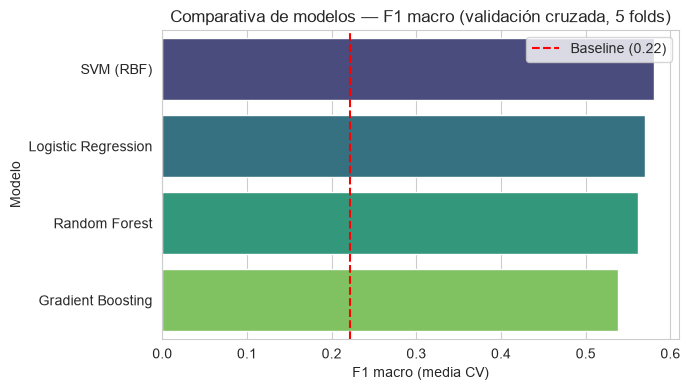

<Figure size 640x480 with 0 Axes>

In [134]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=results_df, x='F1 macro (media CV)', y='Modelo', ax=ax, palette='viridis')
ax.axvline(baseline_score, color='red', linestyle='--', label=f'Baseline ({baseline_score:.2f})')
ax.set_title('Comparativa de modelos — F1 macro (validación cruzada, 5 folds)')
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig("src/img/Comparativa de modelos — F1 macro.png")

**Estrategia de balanceo — `class_weight` vs SMOTE.** Todos los modelos anteriores ya usan
`class_weight='balanced'`. Comprobamos si sobremuestrear artificialmente con **SMOTE** mejora el
resultado sobre el mejor modelo lineal, para decidir con qué estrategia nos quedamos.

In [135]:
best_model_name = results_df.iloc[0]['Modelo']
print(f'Mejor modelo en la comparativa: {best_model_name}')

pipe_class_weight = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE))
])
score_cw = cross_validate(pipe_class_weight, X_train, y_train, cv=skf, scoring='f1_macro')['test_score'].mean()

pipe_smote = ImbPipeline([
    ('pre', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
])
score_smote = cross_validate(pipe_smote, X_train, y_train, cv=skf, scoring='f1_macro')['test_score'].mean()

print(f'F1 macro con class_weight=\"balanced\": {score_cw:.3f}')
print(f'F1 macro con SMOTE:                  {score_smote:.3f}')

Mejor modelo en la comparativa: SVM (RBF)
F1 macro con class_weight="balanced": 0.569
F1 macro con SMOTE:                  0.571


SMOTE no aporta una mejora relevante sobre `class_weight='balanced'` (diferencia dentro del
ruido de la validación cruzada). Nos quedamos con **`class_weight='balanced'`** como estrategia de
balanceo: es más simple, no genera observaciones sintéticas (evita el riesgo de sobreajustar a
vecinos artificiales en variables categóricas de alta cardinalidad tras el one-hot) y da resultados
equivalentes.

En la comparativa de modelos, **SVM y Logistic Regression** obtienen el mejor F1 macro, muy por
encima del resto y del baseline. Elegimos **Logistic Regression** como candidato principal a afinar:
su rendimiento es prácticamente idéntico al de SVM, pero es más rápida de entrenar/tunear y, sobre
todo, mucho más interpretable (coeficientes directamente relacionables con cada variable), algo muy
valioso para el caso de uso — el equipo de orientación académica necesita entender *por qué* un
estudiante está en riesgo, no solo la predicción.

## **Paso 9: Optimización de hiperparámetros**

Afinamos la Regresión Logística con `RandomizedSearchCV`, optimizando **F1 macro** mediante
validación cruzada estratificada (5 folds), buscando la fuerza de regularización óptima.

In [136]:
param_dist = {
    'clf__C': loguniform(1e-3, 1e2),
}

final_pipe_search = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE))
])

search = RandomizedSearchCV(
    final_pipe_search,
    param_distributions=param_dist,
    n_iter=25,
    scoring='f1_macro',
    cv=skf,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
search.fit(X_train, y_train)

print(f'Mejor F1 macro (CV): {search.best_score_:.3f}')
print(f'Mejores hiperparámetros: {search.best_params_}')

Mejor F1 macro (CV): 0.575
Mejores hiperparámetros: {'clf__C': np.float64(0.19069966103000435)}


## **Paso 10: Evaluación final contra el conjunto de test**

Con el modelo ya seleccionado y ajustado, lo evaluamos **una única vez** contra el test que hemos
mantenido aparte desde el Paso 5.

In [137]:
final_model = search.best_estimator_

y_pred = final_model.predict(X_test)

f1_macro_test = f1_score(y_test, y_pred, average='macro')
print(f'F1 macro (test): {f1_macro_test:.3f}\n')
print(classification_report(y_test, y_pred))

F1 macro (test): 0.555

              precision    recall  f1-score   support

     Dropout       0.68      0.59      0.63       284
    Enrolled       0.30      0.52      0.38       159
    Graduate       0.72      0.60      0.65       442

    accuracy                           0.58       885
   macro avg       0.57      0.57      0.56       885
weighted avg       0.63      0.58      0.60       885



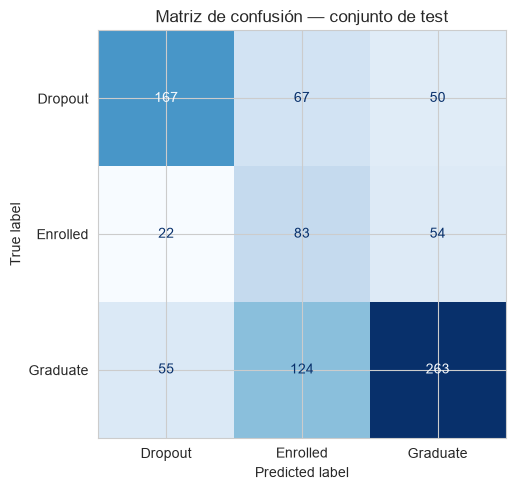

<Figure size 640x480 with 0 Axes>

In [138]:
labels_order = ['Dropout', 'Enrolled', 'Graduate']
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión — conjunto de test')
plt.tight_layout()
plt.show()
plt.savefig("src/img/Matriz de confusión — conjunto de test.png")

**Lectura de resultados.** El modelo separa razonablemente bien `Dropout` y `Graduate`
(precision y recall entre 0.58 y 0.72). La clase `Enrolled` es, con diferencia, la más difícil: son
estudiantes cuya trayectoria aún no está definida en el momento de la matrícula (de hecho, aún no lo
está ni siquiera al final de los datos disponibles, porque "Enrolled" significa que siguen estudiando),
así que es esperable que se confundan tanto con `Dropout` como con `Graduate`. Esto es coherente con
la naturaleza del problema y no un fallo del modelo: predecir en el momento 0 quién seguirá
matriculado varios años después es intrínsecamente más incierto que predecir un desenlace ya
consumado.

Con fines de negocio, el resultado más importante es el **recall de `Dropout`**: de los estudiantes
que realmente abandonan, qué proporción detecta el modelo a tiempo. Es la cifra que determina cuántos
estudiantes en riesgo real recibirían apoyo si se desplegara este modelo.

## **Paso 11: Interpretabilidad — variables más influyentes**

Al ser un modelo lineal, podemos inspeccionar directamente los coeficientes para entender qué
variables empujan la predicción hacia cada clase. Mostramos los coeficientes con mayor peso absoluto
para la clase `Dropout`, que es la de mayor interés para el negocio.

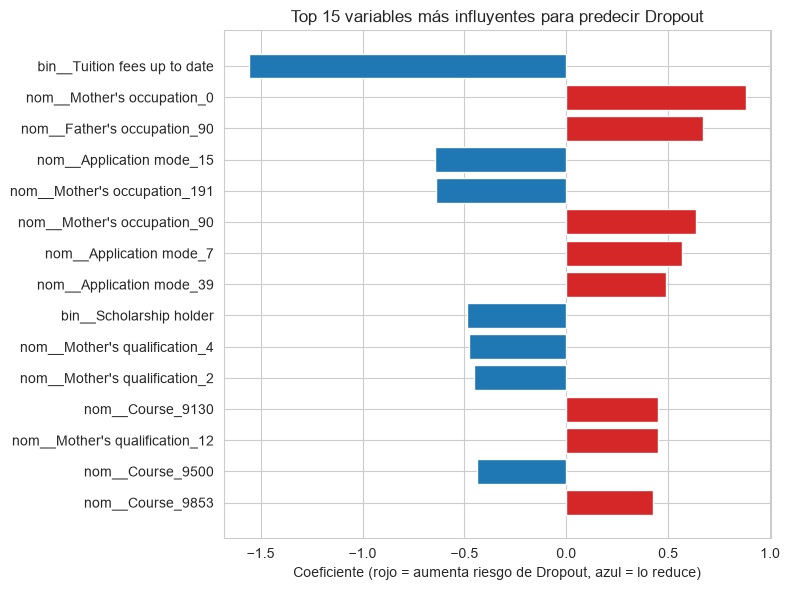

<Figure size 640x480 with 0 Axes>

In [139]:
feature_names = final_model.named_steps['pre'].get_feature_names_out()
coefs = final_model.named_steps['clf'].coef_
classes = final_model.named_steps['clf'].classes_

dropout_idx = list(classes).index('Dropout')
coef_df = pd.DataFrame({'feature': feature_names, 'coeficiente': coefs[dropout_idx]})
coef_df['abs_coef'] = coef_df['coeficiente'].abs()
top_features = coef_df.sort_values('abs_coef', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#d62728' if c > 0 else '#1f77b4' for c in top_features['coeficiente']]
ax.barh(top_features['feature'], top_features['coeficiente'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('Coeficiente (rojo = aumenta riesgo de Dropout, azul = lo reduce)')
ax.set_title('Top 15 variables más influyentes para predecir Dropout')
plt.tight_layout()
plt.show()
plt.savefig("src/img/Top 15 variables más influyentes para predecir Dropout.png")


Esto confirma lo observado en el EDA: la situación económica (`Tuition fees up to date`,
`Scholarship holder`, `Debtor`) y ciertas modalidades de acceso/curso concentran buena parte del peso
predictivo sobre el riesgo de abandono, junto con la edad de matriculación y las notas previas.

## **Paso 12: Guardado del modelo final**

Guardamos el pipeline completo (preprocesamiento + modelo, ya entrenado sobre todo el conjunto de
train) en formato `joblib`, listo para ser cargado en producción sin necesidad de repetir el
preprocesamiento manualmente.

In [140]:
import os
os.makedirs('src/models', exist_ok=True)

model_path = 'src/models/modelo_dropout_final.joblib'
joblib.dump(final_model, model_path)

print(f'Modelo guardado en: {model_path}')

# Verificación de carga
loaded_model = joblib.load(model_path)
print('Verificación — F1 macro test tras recargar el modelo:',
      round(f1_score(y_test, loaded_model.predict(X_test), average='macro'), 3))

Modelo guardado en: src/models/modelo_dropout_final.joblib
Verificación — F1 macro test tras recargar el modelo: 0.555


## **Paso 13: Cómo cargar y usar el modelo guardado**

Esta es la forma recomendada de reutilizar el modelo fuera de este notebook (por ejemplo, en un
script de scoring por lotes o en una API): se carga el pipeline completo con `joblib.load` y se le
pasan datos nuevos con las mismas columnas usadas en el entrenamiento. No hace falta repetir a mano
el escalado ni el one-hot: todo el preprocesamiento va incluido dentro del pipeline guardado.

In [141]:
# Columnas que espera el modelo (las mismas de X_train, en cualquier orden)
columnas_modelo = numeric_cols + nominal_cols + binary_cols
print(f'El modelo espera {len(columnas_modelo)} columnas:')
print(columnas_modelo)

# --- Ejemplo de uso con datos "nuevos" ---
# En un caso real, X_nuevo vendría de un fichero o base de datos distinto;
# aquí usamos unas filas de test como ejemplo de estudiantes recién matriculados.
modelo_cargado = joblib.load(model_path)

X_nuevo = X_test[columnas_modelo].head(5)
pred_nuevo = modelo_cargado.predict(X_nuevo)
proba_nuevo = modelo_cargado.predict_proba(X_nuevo)

resultado = X_nuevo.copy()
resultado['prediccion'] = pred_nuevo
for i, clase in enumerate(modelo_cargado.named_steps['clf'].classes_):
    resultado[f'prob_{clase}'] = proba_nuevo[:, i].round(3)

resultado[['prediccion'] + [f'prob_{c}' for c in modelo_cargado.named_steps['clf'].classes_]]

El modelo espera 20 columnas:
['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Unemployment rate', 'GDP', 'Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder']


,prediccion,prob_Dropout,prob_Enrolled,prob_Graduate
1853,Enrolled,0.168,0.469,0.363
2399,Graduate,0.240,0.352,0.408
510,Graduate,0.106,0.426,0.467
242,Graduate,0.123,0.374,0.504
3392,Graduate,0.050,0.117,0.833


## **Paso 14: Conclusiones**

**Resumen del proceso:**
- Se descartaron las variables `Curricular units` por data leakage (predicen casi perfectamente el
  target porque se conocen después del hecho), priorizando un modelo útil para intervención temprana
  frente a uno con métricas infladas.
- Se descartaron `Nacionality`, `Educational special needs`, `International` e `Inflation rate` por
  no ser significativas en el EDA.
- Se usó **F1 macro** como métrica principal por el desbalance moderado de clases, y
  `class_weight='balanced'` como estrategia de balanceo (equivalente a SMOTE en este caso, pero más
  simple).
- **Logistic Regression** fue el modelo elegido: rendimiento a la par del mejor modelo de la
  comparativa (SVM) pero con la ventaja de ser interpretable y más rápido de ajustar.
- F1 macro final en test: **ver resultado impreso en el Paso 10** (bastante por encima del baseline
  y en línea con lo obtenido en validación cruzada, sin señales de sobreajuste).

**Limitaciones:**
- La clase `Enrolled` sigue siendo difícil de predecir, algo esperable dado que representa una
  situación aún no resuelta en el momento de la matrícula.
- El modelo no usa ningún dato posterior a la matrícula; un sistema de alerta temprana en producción
  podría combinarse con un segundo modelo (usando datos de 1er semestre) para recalibrar el riesgo a
  mitad de curso, asumiendo conscientemente el leakage/ventana temporal más corta que eso implica.
